# 🛒 Stage 6: Customer Segmentation for E-Commerce
### ML Roadmap — Clustering (Unsupervised Learning) Project


## Step 0: Install & Import Libraries

In [2]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster       import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors     import NearestNeighbors
from sklearn.metrics       import (silhouette_score,
                                   davies_bouldin_score,
                                   calinski_harabasz_score)
from mpl_toolkits.mplot3d  import Axes3D

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

import sklearn
print(f'✅ All libraries imported  |  scikit-learn {sklearn.__version__}')

✅ All libraries imported  |  scikit-learn 1.8.0


---
## Step 1: Generate & Load the Dataset


In [ ]:
def generate_ecommerce_customers(n=4000, seed=42):
    """
    Realistic synthetic e-commerce customer dataset.

    Columns
    -------
    recency_days      : Days since last purchase  (lower = more recent)
    frequency         : Orders placed in last 12 months
    monetary          : Total spend ₹ in last 12 months
    avg_order_value   : monetary / frequency
    days_as_customer  : Tenure in days
    num_categories    : Distinct product categories purchased
    num_returns       : Number of returns
    promo_used        : Coupons / promotions used
    avg_rating_given  : Mean product rating given (1-5)
    mobile_orders_pct : % of orders via mobile app
    true_segment      : Hidden label for validation only (NOT used in clustering)
    """
    np.random.seed(seed)

    cities = ['Chennai','Coimbatore','Madurai','Bengaluru','Mumbai',
              'Delhi','Hyderabad','Pune','Kochi','Trichy']
    cats   = ['Electronics','Fashion','Grocery','Home','Beauty','Sports','Books']

    # ── Four hidden archetypes ─────────────────────────────────────────────
    segment_raw = np.random.choice(
        ['Champions','Loyal','AtRisk','Lost'], n, p=[0.18, 0.30, 0.28, 0.24])

    rfm_params = {
        'Champions': dict(rec_mu=15,  rec_sd=10, freq_mu=18, freq_sd=5,  mon_mu=28000, mon_sd=8000),
        'Loyal':     dict(rec_mu=45,  rec_sd=20, freq_mu=10, freq_sd=3,  mon_mu=12000, mon_sd=4000),
        'AtRisk':    dict(rec_mu=120, rec_sd=40, freq_mu=5,  freq_sd=2,  mon_mu=6000,  mon_sd=2500),
        'Lost':      dict(rec_mu=280, rec_sd=60, freq_mu=2,  freq_sd=1,  mon_mu=2000,  mon_sd=1000),
    }

    recency = np.zeros(n); frequency = np.zeros(n); monetary = np.zeros(n)
    for seg, p in rfm_params.items():
        m = segment_raw == seg
        recency[m]   = np.clip(np.random.normal(p['rec_mu'],  p['rec_sd'],  m.sum()), 1, 365)
        frequency[m] = np.clip(np.random.normal(p['freq_mu'], p['freq_sd'], m.sum()), 1, 30).round(0)
        monetary[m]  = np.clip(np.random.normal(p['mon_mu'],  p['mon_sd'],  m.sum()), 200, 80000)

    # ── 12% realistic noise / overlap ─────────────────────────────────────
    ni = np.random.choice(n, int(n * 0.12), replace=False)
    recency[ni]  = np.clip(recency[ni]  * np.random.uniform(0.5, 2.0, len(ni)), 1, 365)
    monetary[ni] = np.clip(monetary[ni] * np.random.uniform(0.5, 2.0, len(ni)), 200, 80000)

    recency   = recency.round(0).astype(int)
    frequency = frequency.round(0).astype(int)

    return pd.DataFrame({
        'customer_id':       [f'CUST{10000+i}' for i in range(n)],
        'city':              np.random.choice(cities, n, p=[0.18,0.10,0.07,0.15,0.13,0.12,0.10,0.07,0.05,0.03]),
        'age':               np.clip(np.random.normal(34, 11, n), 18, 70).round(0).astype(int),
        'gender':            np.random.choice(['Male','Female','Other'], n, p=[0.52,0.45,0.03]),
        'recency_days':      recency,
        'frequency':         frequency,
        'monetary':          monetary.round(2),
        'avg_order_value':   (monetary / np.where(frequency == 0, 1, frequency)).round(2),
        'days_as_customer':  np.clip(np.random.normal(600, 300, n), 30, 1800).round(0).astype(int),
        'num_categories':    np.clip(np.random.normal(3.5, 1.5, n), 1, 8).round(0).astype(int),
        'num_returns':       np.clip(np.random.exponential(0.8, n), 0, 8).round(0).astype(int),
        'promo_used':        np.clip(np.random.normal(2.5, 2, n), 0, 15).round(0).astype(int),
        'avg_rating_given':  np.clip(np.random.normal(3.8, 0.8, n), 1, 5).round(1),
        'mobile_orders_pct': np.clip(np.random.normal(65, 20, n), 0, 100).round(1),
        'last_category':     np.random.choice(cats, n, p=[0.20,0.25,0.18,0.15,0.10,0.07,0.05]),
        'true_segment':      segment_raw,
    })


df = generate_ecommerce_customers(n=4000)
# df.to_csv('ecommerce_customers.csv', index=False)

# ── OR load the provided CSV ──
df = pd.read_csv('ecommerce_customers.csv')

print(f'✅ Dataset: {df.shape[0]:,} customers × {df.shape[1]} features')
print(f'\nHidden segment counts (for validation — NOT used in clustering):')
print(df['true_segment'].value_counts().to_string())
print(f'\nRFM Summary:')
print(df[['recency_days','frequency','monetary']].describe().round(1).to_string())
df.head()


✅ Dataset: 4,000 customers × 16 features

Hidden segment counts (for validation — NOT used in clustering):
true_segment
Loyal        1203
AtRisk       1105
Lost          978
Champions     714

RFM Summary:
       recency_days  frequency  monetary
count       4000.00    4000.00   4000.00
mean         120.10       8.20  11034.10
std          107.50       6.30  10362.40
min            1.00       1.00    200.00
25%           32.00       3.00   3083.10
50%           79.00       7.00   7833.40
75%          188.00      12.00  14872.10
max          365.00      30.00  65039.10


,customer_id,city,age,gender,recency_days,frequency,monetary,avg_order_value,days_as_customer,num_categories,num_returns,promo_used,avg_rating_given,mobile_orders_pct,last_category,true_segment
0,CUST10000,Bengaluru,49,Male,60,13,11599.20,1183.40,507,2,0,0,3.70,72.10,Home,Loyal
1,CUST10001,Kochi,37,Male,29,19,25132.84,1322.78,502,2,0,3,3.50,68.70,Grocery,Champions
2,CUST10002,Delhi,27,Male,94,14,5034.03,359.57,715,3,0,1,4.60,53.70,Fashion,Loyal
3,CUST10003,Mumbai,39,Other,225,3,4587.25,1529.08,940,5,0,4,4.90,58.00,Home,Lost
4,CUST10004,Chennai,29,Male,161,9,10718.88,1190.99,456,4,0,1,4.10,53.00,Beauty,AtRisk


---
## Step 2: RFM Scoring & EDA


RFM Score distribution:
RFM_score
3     386
4     425
5     212
6     196
7     333
8     362
9     199
10    230
11    365
12    366
13    226
14    232
15    468


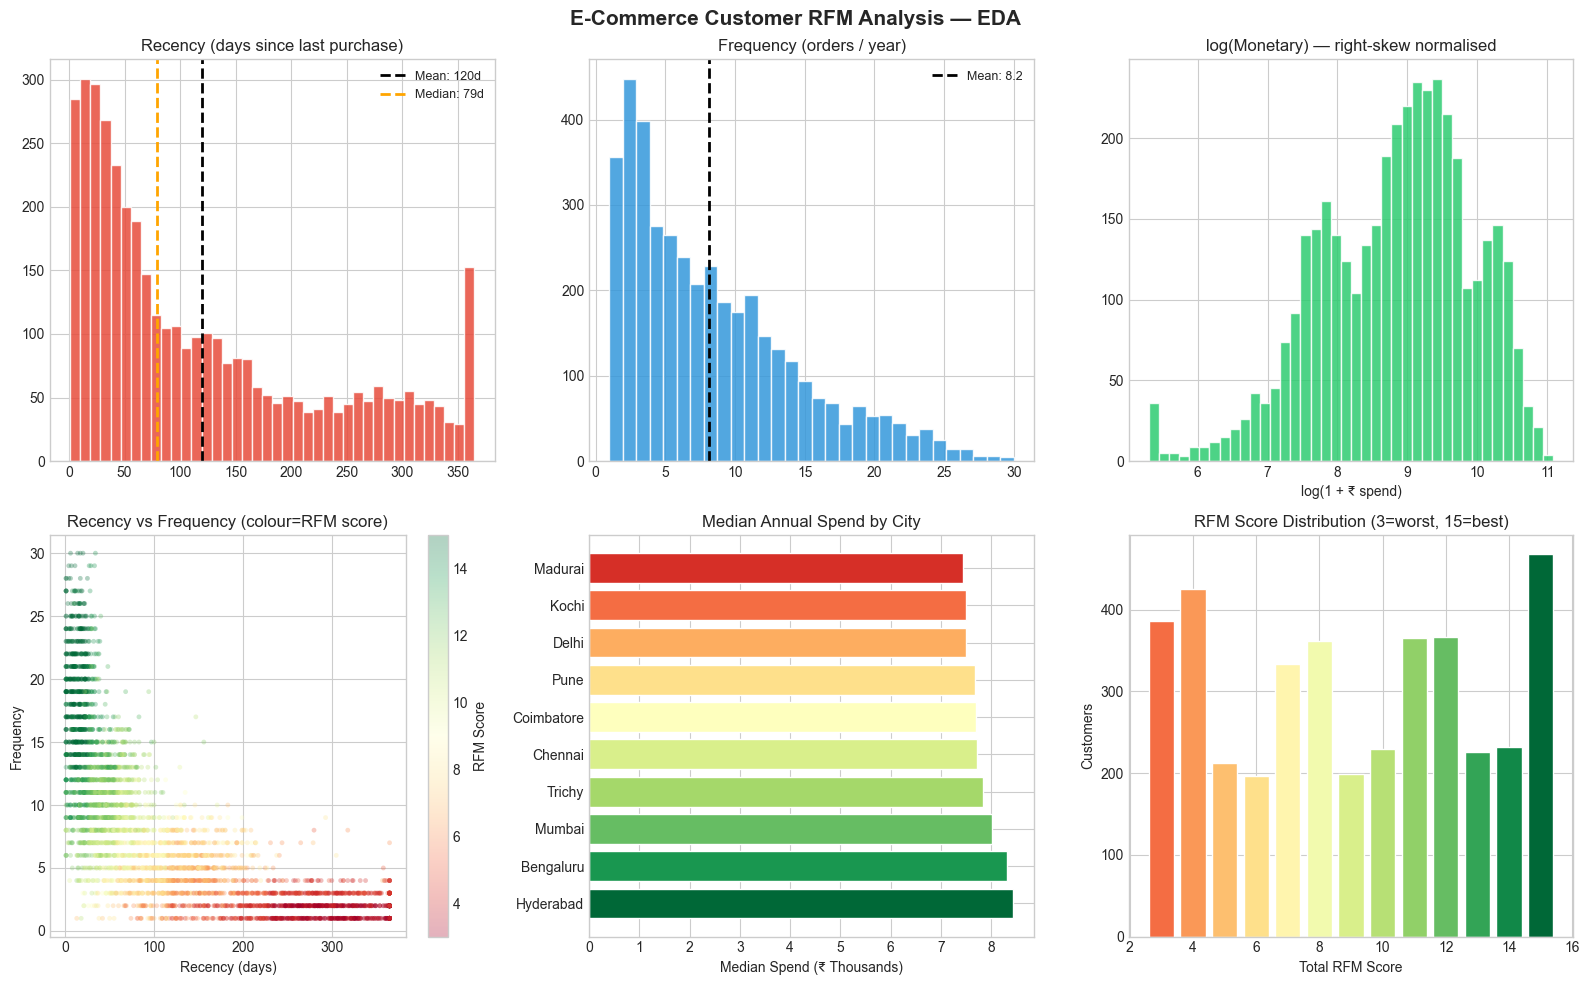

💾 Saved: cs_01_eda.png


In [ ]:

# ── RFM Scores (quintiles, 5 = best) ─────────────────────────────────────────
df['R_score']   = pd.qcut(df['recency_days'], 5, labels=[5,4,3,2,1]).astype(int) # Customers-ஐ 5 groups-ஆ divide செய்கிறோம்.
df['F_score']   = pd.qcut(df['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
df['M_score']   = pd.qcut(df['monetary'],    5, labels=[1,2,3,4,5]).astype(int)
df['RFM_score'] = df['R_score'] + df['F_score'] + df['M_score']

print('RFM Score distribution:')
print(df['RFM_score'].value_counts().sort_index().to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('E-Commerce Customer RFM Analysis — EDA', fontsize=15, fontweight='bold')

# Recency
axes[0,0].hist(df['recency_days'], bins=40, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['recency_days'].mean(),   color='black',  ls='--', lw=2,
                  label=f'Mean: {df["recency_days"].mean():.0f}d')
axes[0,0].axvline(df['recency_days'].median(), color='orange', ls='--', lw=2,
                  label=f'Median: {df["recency_days"].median():.0f}d')
axes[0,0].set_title('Recency (days since last purchase)'); axes[0,0].legend(fontsize=9)

axes[0,1].hist(df['frequency'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0,1].axvline(df['frequency'].mean(), color='black', ls='--', lw=2,
                  label=f'Mean: {df["frequency"].mean():.1f}')
axes[0,1].set_title('Frequency (orders / year)'); axes[0,1].legend(fontsize=9)

# Log Monetary
axes[0,2].hist(np.log1p(df['monetary']), bins=40, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0,2].set_title('log(Monetary) — right-skew normalised')
axes[0,2].set_xlabel('log(1 + ₹ spend)') 


sc = axes[1,0].scatter(df['recency_days'], df['frequency'],
    c=df['RFM_score'], cmap='RdYlGn', alpha=0.3, s=12, edgecolors='none')
plt.colorbar(sc, ax=axes[1,0], label='RFM Score')
axes[1,0].set_title('Recency vs Frequency (colour=RFM score)')
axes[1,0].set_xlabel('Recency (days)'); axes[1,0].set_ylabel('Frequency')

city_med = df.groupby('city')['monetary'].median().sort_values(ascending=False)
axes[1,1].barh(city_med.index, city_med.values / 1000,
               color=plt.cm.RdYlGn(city_med.rank() / len(city_med)), edgecolor='white')
axes[1,1].set_title('Median Annual Spend by City')
axes[1,1].set_xlabel('Median Spend (₹ Thousands)')

rfm_cnt = df['RFM_score'].value_counts().sort_index()
axes[1,2].bar(rfm_cnt.index, rfm_cnt.values,
              color=plt.cm.RdYlGn(rfm_cnt.index / 15), edgecolor='white')
axes[1,2].set_title('RFM Score Distribution (3=worst, 15=best)')
axes[1,2].set_xlabel('Total RFM Score'); axes[1,2].set_ylabel('Customers')

plt.tight_layout()
plt.savefig('cs_01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cs_01_eda.png')


## Step 3: Feature Preparation — Log-Transform & Standard Scaling


In [ ]:
CLUSTER_FEATURES = [
    'recency_days', 'frequency', 'monetary', 'avg_order_value',
    'num_categories', 'num_returns', 'promo_used',
    'avg_rating_given', 'mobile_orders_pct', 'days_as_customer'
] 
X = df[CLUSTER_FEATURES].copy()

# Log-transform right-skewed columns before scaling
SKEWED = ['monetary', 'avg_order_value', 'recency_days', 'days_as_customer']
for col in SKEWED:
    X[f'log_{col}'] = np.log1p(X[col])
    X.drop(columns=[col], inplace=True)

feature_names = X.columns.tolist()
print(f'Features after log-transform: {feature_names}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\n✅ Feature matrix: {X_scaled.shape}')
print(f'   Mean  (should be ≈0): {X_scaled.mean(axis=0).round(2)}')
print(f'   Std   (should be ≈1): {X_scaled.std(axis=0).round(2)}')

Features after log-transform: ['frequency', 'num_categories', 'num_returns', 'promo_used', 'avg_rating_given', 'mobile_orders_pct', 'log_monetary', 'log_avg_order_value', 'log_recency_days', 'log_days_as_customer']

✅ Feature matrix: (4000, 10)
   Mean  (should be ≈0): [ 0. -0. -0. -0. -0.  0. -0. -0. -0.  0.]
   Std   (should be ≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]



## Step 4: Find Optimal K — Four Metrics


In [ ]:
inertias, silhouettes, db_scores, ch_scores = [], [], [], [] 
K_range = range(2, 11)

print('Computing metrics for K=2..10 ...')
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=SEED, n_init=10) 

    lbl = km.fit_predict(X_scaled) 
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl, sample_size=1000, random_state=SEED))
    db_scores.append(davies_bouldin_score(X_scaled, lbl))
    ch_scores.append(calinski_harabasz_score(X_scaled, lbl))
    print(f'  K={k:2d} | Silhouette={silhouettes[-1]:.4f} | DB={db_scores[-1]:.4f} | '
          f'CH={ch_scores[-1]:.0f} | Inertia={inertias[-1]:.0f}')

print(f'\n→ Best Silhouette : K={list(K_range)[np.argmax(silhouettes)]}') 
print(f'→ Best DB          : K={list(K_range)[np.argmin(db_scores)]}') 
print(f'→ Best CH          : K={list(K_range)[np.argmax(ch_scores)]}') 


Computing metrics for K=2..10 ...
  K= 2 | Silhouette=0.1575 | DB=2.0371 | CH=885 | Inertia=32752
  K= 3 | Silhouette=0.1060 | DB=2.3824 | CH=618 | Inertia=30548
  K= 4 | Silhouette=0.1157 | DB=2.1289 | CH=524 | Inertia=28705
  K= 5 | Silhouette=0.1199 | DB=2.0185 | CH=470 | Inertia=27193
  K= 6 | Silhouette=0.1054 | DB=2.0201 | CH=435 | Inertia=25902
  K= 7 | Silhouette=0.0990 | DB=1.9962 | CH=406 | Inertia=24832
  K= 8 | Silhouette=0.0961 | DB=2.0097 | CH=383 | Inertia=23933
  K= 9 | Silhouette=0.0937 | DB=1.9206 | CH=361 | Inertia=23210
  K=10 | Silhouette=0.0930 | DB=1.8804 | CH=342 | Inertia=22566

→ Best Silhouette : K=2
→ Best DB          : K=10
→ Best CH          : K=2


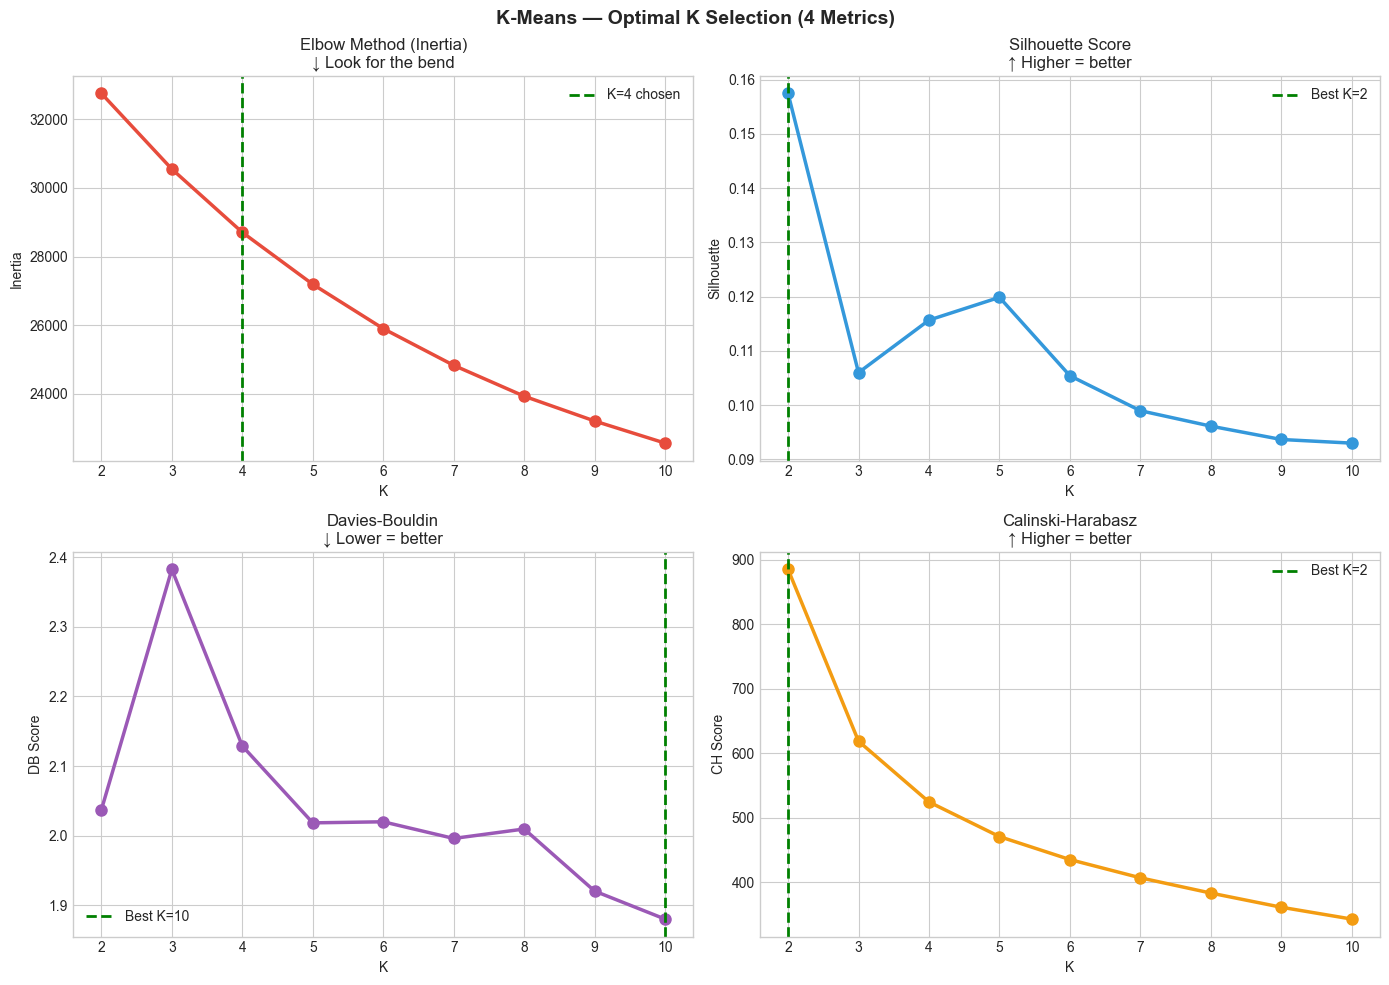

💾 Saved: cs_02_optimal_k.png

💡 We choose K=4 — aligns with 4 business archetypes and elbow at K=4


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K-Means — Optimal K Selection (4 Metrics)', fontsize=14, fontweight='bold')

def plot_metric(ax, vals, title, ylabel, best_fn=np.argmax, color='#3498db', label_prefix='Best'):
    best_k = list(K_range)[best_fn(vals)]
    ax.plot(K_range, vals, 'o-', color=color, lw=2.5, ms=8)
    ax.axvline(best_k, color='green', ls='--', lw=2, label=f'{label_prefix} K={best_k}')
    ax.set_title(title); ax.set_xlabel('K'); ax.set_ylabel(ylabel); ax.legend()

axes[0,0].plot(K_range, inertias, 'o-', color='#e74c3c', lw=2.5, ms=8)
axes[0,0].axvline(4, color='green', ls='--', lw=2, label='K=4 chosen')
axes[0,0].set_title('Elbow Method (Inertia)\n↓ Look for the bend')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('Inertia'); axes[0,0].legend()

plot_metric(axes[0,1], silhouettes, 'Silhouette Score\n↑ Higher = better', 'Silhouette', color='#3498db')
plot_metric(axes[1,0], db_scores,   'Davies-Bouldin\n↓ Lower = better',    'DB Score',   color='#9b59b6', best_fn=np.argmin)
plot_metric(axes[1,1], ch_scores,   'Calinski-Harabasz\n↑ Higher = better','CH Score',   color='#f39c12')

plt.tight_layout()
plt.savefig('cs_02_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cs_02_optimal_k.png')
print('\n💡 We choose K=4 — aligns with 4 business archetypes and elbow at K=4')


## Step 5: Fit K-Means (K=4) & Visualise with PCA


In [ ]:

K_BEST = 4 
kmeans = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=20, max_iter=500)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['kmeans_cluster'], sample_size=1000, random_state=SEED)
db  = davies_bouldin_score(X_scaled, df['kmeans_cluster'])
ch  = calinski_harabasz_score(X_scaled, df['kmeans_cluster'])

print(f'✅ K-Means fitted (K={K_BEST})')
print(f'   Silhouette  : {sil:.4f}  (higher=better, max=1.0)')
print(f'   Davies-Bouldin: {db:.4f}  (lower=better)')
print(f'   Calinski-Harabasz: {ch:.0f} (higher=better)')
print(f'\nCluster sizes:')
print(df['kmeans_cluster'].value_counts().sort_index().to_string())


✅ K-Means fitted (K=4)
   Silhouette  : 0.1157  (higher=better, max=1.0)
   Davies-Bouldin: 2.1285  (lower=better)
   Calinski-Harabasz: 524 (higher=better)

Cluster sizes:
kmeans_cluster
0    1449
1     834
2     283
3    1434


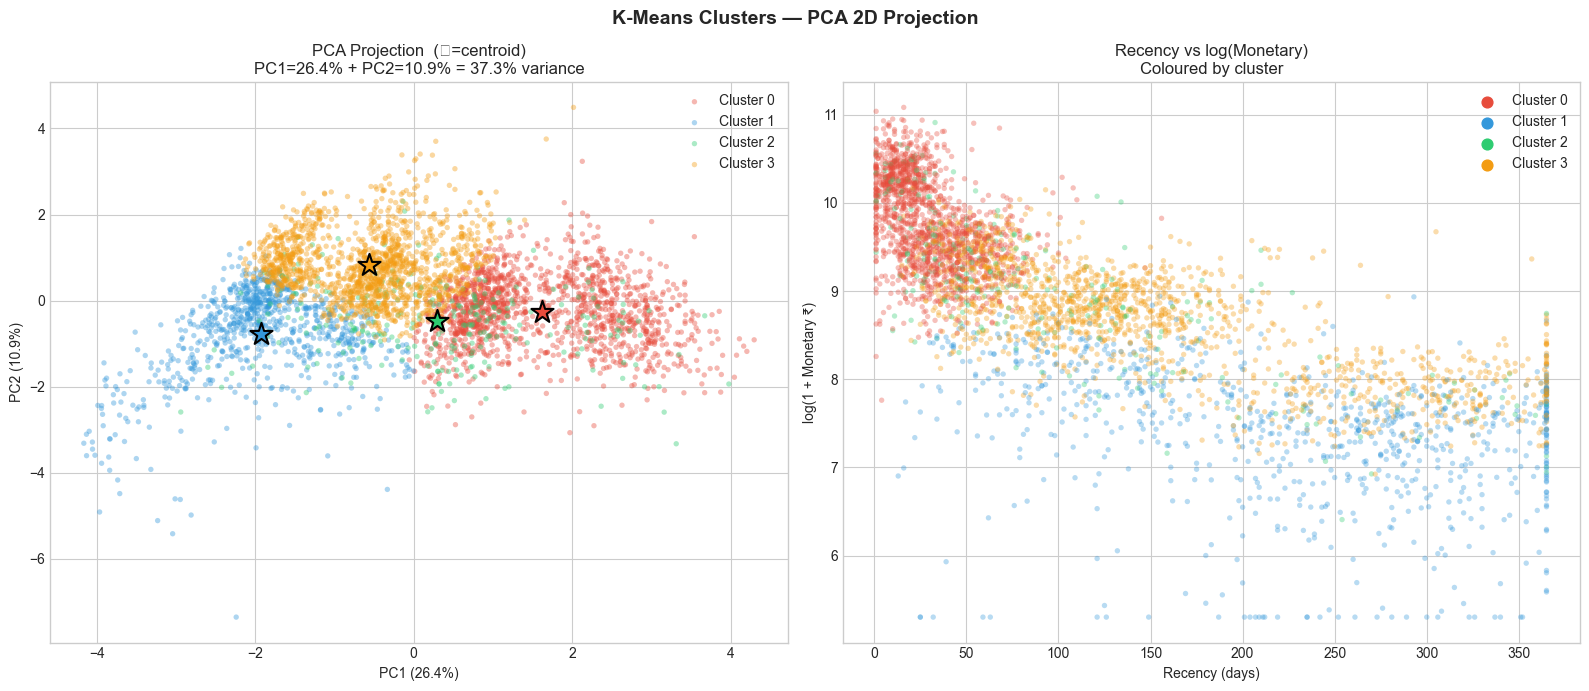

💾 Saved: cs_03_pca_clusters.png


In [ ]:

# PCA 2D projection
pca2 = PCA(n_components=2, random_state=SEED) 
X_pca = pca2.fit_transform(X_scaled) 
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('K-Means Clusters — PCA 2D Projection', fontsize=14, fontweight='bold')

# PCA scatter
for k in range(K_BEST):
    m = df['kmeans_cluster'] == k
    axes[0].scatter(df.loc[m, 'pca1'], df.loc[m, 'pca2'],
        c=CLUSTER_COLORS[k], alpha=0.4, s=15, edgecolors='none', label=f'Cluster {k}')

ctr_pca = pca2.transform(kmeans.cluster_centers_)
for k in range(K_BEST):
    axes[0].scatter(ctr_pca[k, 0], ctr_pca[k, 1],
        c=CLUSTER_COLORS[k], s=280, marker='*', edgecolors='black', lw=1.5, zorder=10)

v1 = pca2.explained_variance_ratio_[0] * 100
v2 = pca2.explained_variance_ratio_[1] * 100
axes[0].set_title(f'PCA Projection  (★=centroid)\nPC1={v1:.1f}% + PC2={v2:.1f}% = {v1+v2:.1f}% variance')
axes[0].set_xlabel(f'PC1 ({v1:.1f}%)'); axes[0].set_ylabel(f'PC2 ({v2:.1f}%)')
axes[0].legend(fontsize=10)

# Recency
axes[1].scatter(df['recency_days'], np.log1p(df['monetary']),
    c=[CLUSTER_COLORS[k] for k in df['kmeans_cluster']],
    alpha=0.35, s=15, edgecolors='none')
axes[1].set_title('Recency vs log(Monetary)\nColoured by cluster')
axes[1].set_xlabel('Recency (days)'); axes[1].set_ylabel('log(1 + Monetary ₹)')
handles = [plt.scatter([], [], c=CLUSTER_COLORS[k], s=60, label=f'Cluster {k}') for k in range(K_BEST)]
axes[1].legend(handles=handles, fontsize=10)

plt.tight_layout()
plt.savefig('cs_03_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cs_03_pca_clusters.png')


---
## Step 6: Label Clusters — Auto-Name Each Segment


In [ ]:


cluster_profile = df.groupby('kmeans_cluster').agg(
    Customers     = ('customer_id',      'count'),
    Recency       = ('recency_days',     'mean'),
    Frequency     = ('frequency',        'mean'),
    Monetary      = ('monetary',         'mean'),
    AvgOrder      = ('avg_order_value',  'mean'),
    Categories    = ('num_categories',   'mean'),
    Returns       = ('num_returns',      'mean'),
    Rating        = ('avg_rating_given', 'mean'),
    Mobile_pct    = ('mobile_orders_pct','mean'),
).round(1)

# Auto-rank: lower Recency is better → invert; higher F/M is better
cluster_profile['rfm_rank'] = (
      cluster_profile['Recency'].rank()   * -1
    + cluster_profile['Frequency'].rank()
    + cluster_profile['Monetary'].rank()
)
rank_order = cluster_profile['rfm_rank'].rank(ascending=False).astype(int)
LABEL_MAP  = {k: ['Champions','Loyal Customers','At-Risk','Lost'][rank_order[k] - 1]
              for k in range(K_BEST)}

df['segment'] = df['kmeans_cluster'].map(LABEL_MAP)
cluster_profile['Segment'] = cluster_profile.index.map(LABEL_MAP)

print('Cluster Profile (auto-labelled):')
display_cols = ['Segment','Customers','Recency','Frequency','Monetary','AvgOrder','Rating']
print(cluster_profile[display_cols].to_string())
print(f'\nLabel map: {LABEL_MAP}')


Cluster Profile (auto-labelled):
                        Segment  Customers  Recency  Frequency  Monetary  AvgOrder  Rating
kmeans_cluster                                                                            
0                     Champions       1449    29.90      14.50  20262.60   1410.30    3.80
1                          Lost        834   223.70       3.90   2084.60    597.90    3.80
2               Loyal Customers        283    98.50       8.80  11676.80   1397.10    3.70
3                       At-Risk       1434   155.30       4.20   6787.10   1924.70    3.80

Label map: {0: 'Champions', 1: 'Lost', 2: 'Loyal Customers', 3: 'At-Risk'}


---
## Step 7: Visualise Segment Profiles


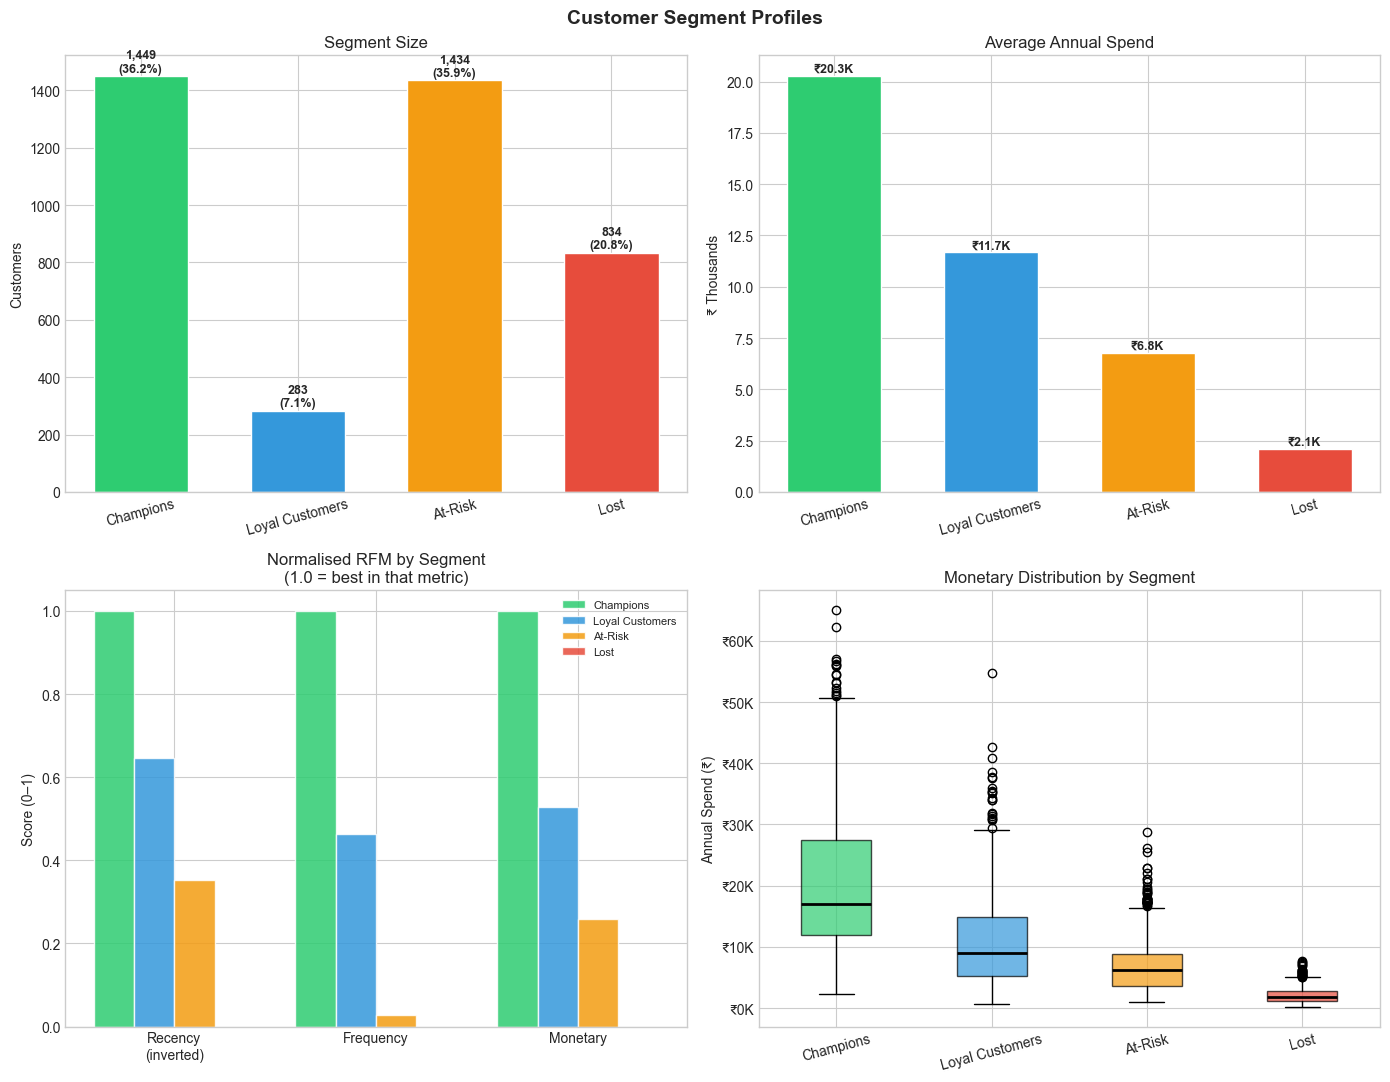

💾 Saved: cs_04_segment_profiles.png


In [ ]:
SEG_COLORS = {
    'Champions':'#2ecc71', 'Loyal Customers':'#3498db',
    'At-Risk':'#f39c12',   'Lost':'#e74c3c'
}
SEG_ORDER = ['Champions', 'Loyal Customers', 'At-Risk', 'Lost']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Customer Segment Profiles', fontsize=14, fontweight='bold')

# 1. Segment
seg_counts = df['segment'].value_counts()
seg_vals   = [seg_counts.get(s, 0) for s in SEG_ORDER]
seg_cols   = [SEG_COLORS[s] for s in SEG_ORDER]

bars = axes[0, 0].bar(SEG_ORDER, seg_vals, color=seg_cols, edgecolor='white', width=0.6)
axes[0, 0].set_title('Segment Size'); axes[0, 0].set_ylabel('Customers')
axes[0, 0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, seg_vals):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, v + 15,
        f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')

# 2. Avg spend
seg_mon = df.groupby('segment')['monetary'].mean()
mon_vals = [seg_mon.get(s, 0) / 1000 for s in SEG_ORDER]
bars2 = axes[0, 1].bar(SEG_ORDER, mon_vals, color=seg_cols, edgecolor='white', width=0.6)
axes[0, 1].set_title('Average Annual Spend'); axes[0, 1].set_ylabel('₹ Thousands')
axes[0, 1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars2, mon_vals):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, v + 0.2,
        f'₹{v:.1f}K', ha='center', fontsize=9, fontweight='bold')

# 3. Normalised RFM bars (Recency, Frequency, Monetary 
metrics = ['Recency', 'Frequency', 'Monetary']
x = np.arange(len(metrics)); w = 0.2
for i, seg in enumerate(SEG_ORDER):
    cid = [k for k, v in LABEL_MAP.items() if v == seg][0]
    row = cluster_profile.loc[cid]
    norm_vals = []
    for m in metrics:
        col_vals = cluster_profile[m]
        nv = (1 - (row[m] - col_vals.min()) / (col_vals.max() - col_vals.min() + 1e-9)
              if m == 'Recency'
              else (row[m] - col_vals.min()) / (col_vals.max() - col_vals.min() + 1e-9))
        norm_vals.append(nv)
    axes[1, 0].bar(x + i * w, norm_vals, w, label=seg,
        color=SEG_COLORS[seg], edgecolor='white', alpha=0.85)

axes[1, 0].set_xticks(x + w * 1.5)
axes[1, 0].set_xticklabels(['Recency\n(inverted)', 'Frequency', 'Monetary'])
axes[1, 0].set_title('Normalised RFM by Segment\n(1.0 = best in that metric)')
axes[1, 0].set_ylabel('Score (0–1)'); axes[1, 0].legend(fontsize=8)

# 4. Monetary boxplot
seg_data = [df[df['segment'] == s]['monetary'].values for s in SEG_ORDER]
bp = axes[1, 1].boxplot(seg_data, labels=SEG_ORDER, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, s in zip(bp['boxes'], SEG_ORDER):
    patch.set_facecolor(SEG_COLORS[s]); patch.set_alpha(0.7)
axes[1, 1].set_title('Monetary Distribution by Segment'); axes[1, 1].set_ylabel('Annual Spend (₹)')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('cs_04_segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cs_04_segment_profiles.png')


---
## Step 8: DBSCAN — Density-Based Clustering



3-Component PCA explains 47.8% of variance


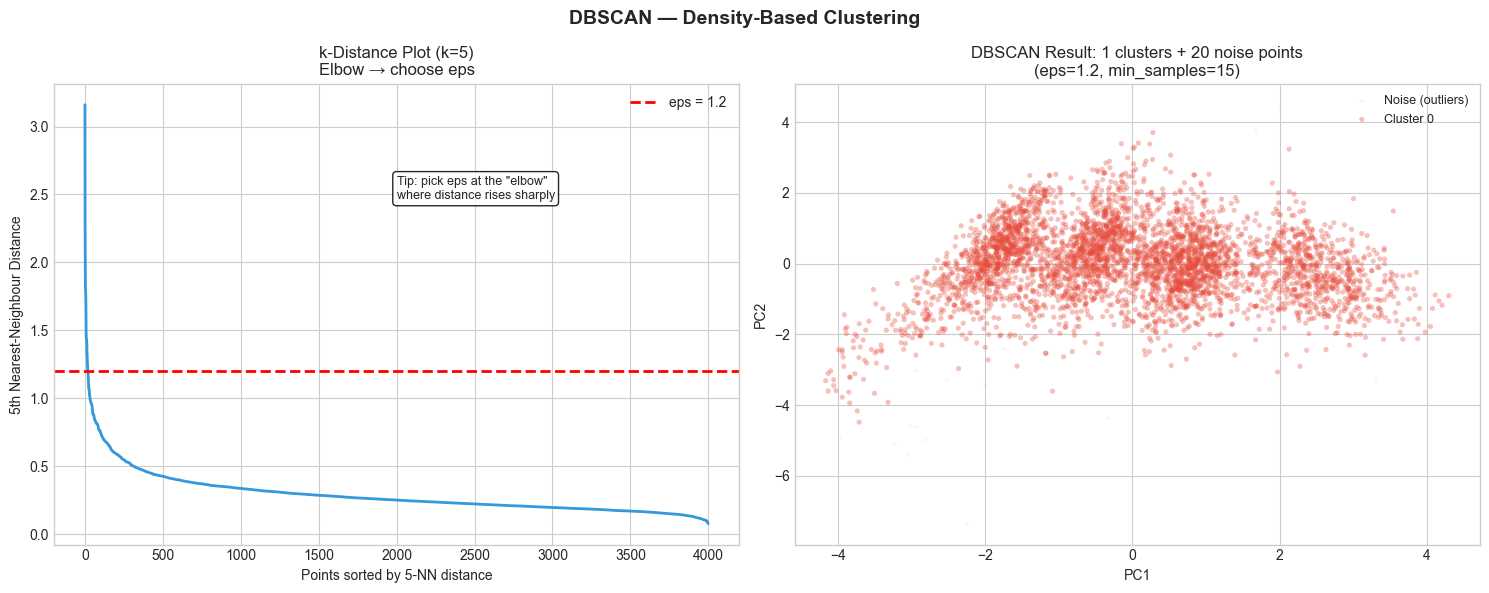

💾 Saved: cs_05_dbscan.png

DBSCAN: 1 cluster(s), 20 noise/outlier points
→ Noise points = anomalous customers worth manual investigation (possible fraud/VIP)


In [ ]:

pca3  = PCA(n_components=3, random_state=SEED)
X_3c  = pca3.fit_transform(X_scaled)
print(f'3-Component PCA explains {pca3.explained_variance_ratio_.sum()*100:.1f}% of variance') 

# k-Distance plot to pick eps
nbrs        = NearestNeighbors(n_neighbors=5).fit(X_3c)
distances, _ = nbrs.kneighbors(X_3c)
k_dist       = np.sort(distances[:, 4])[::-1] 
dbscan            = DBSCAN(eps=1.2, min_samples=15) 
df['dbscan_label'] = dbscan.fit_predict(X_3c)

n_db   = len(set(df['dbscan_label'])) - (1 if -1 in df['dbscan_label'].values else 0) # Count Clusters & Noise
n_nois = (df['dbscan_label'] == -1).sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('DBSCAN — Density-Based Clustering', fontsize=14, fontweight='bold')

# k-distance
axes[0].plot(range(len(k_dist)), k_dist, color='#3498db', lw=2)
axes[0].axhline(1.2, color='red', ls='--', lw=2, label='eps = 1.2')
axes[0].set_title('k-Distance Plot (k=5)\nElbow → choose eps'); axes[0].legend()
axes[0].set_xlabel('Points sorted by 5-NN distance')
axes[0].set_ylabel('5th Nearest-Neighbour Distance')
axes[0].text(0.5, 0.75,
    'Tip: pick eps at the "elbow"\nwhere distance rises sharply',
    transform=axes[0].transAxes, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

DB_CMAP = {-1:'#cccccc', 0:'#e74c3c', 1:'#3498db', 2:'#2ecc71', 3:'#f39c12', 4:'#9b59b6'}
for lbl in sorted(df['dbscan_label'].unique()):
    m = df['dbscan_label'] == lbl
    axes[1].scatter(df.loc[m, 'pca1'], df.loc[m, 'pca2'],
        c=DB_CMAP.get(lbl, '#888888'),
        alpha=0.35 if lbl != -1 else 0.15,
        s=14 if lbl != -1 else 8, edgecolors='none',
        label='Noise (outliers)' if lbl == -1 else f'Cluster {lbl}')
axes[1].set_title(f'DBSCAN Result: {n_db} clusters + {n_nois} noise points\n'
    '(eps=1.2, min_samples=15)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('cs_05_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cs_05_dbscan.png')
print(f'\nDBSCAN: {n_db} cluster(s), {n_nois} noise/outlier points')
print('→ Noise points = anomalous customers worth manual investigation (possible fraud/VIP)')



## Step 9: Business Impact — Revenue & Marketing Strategy


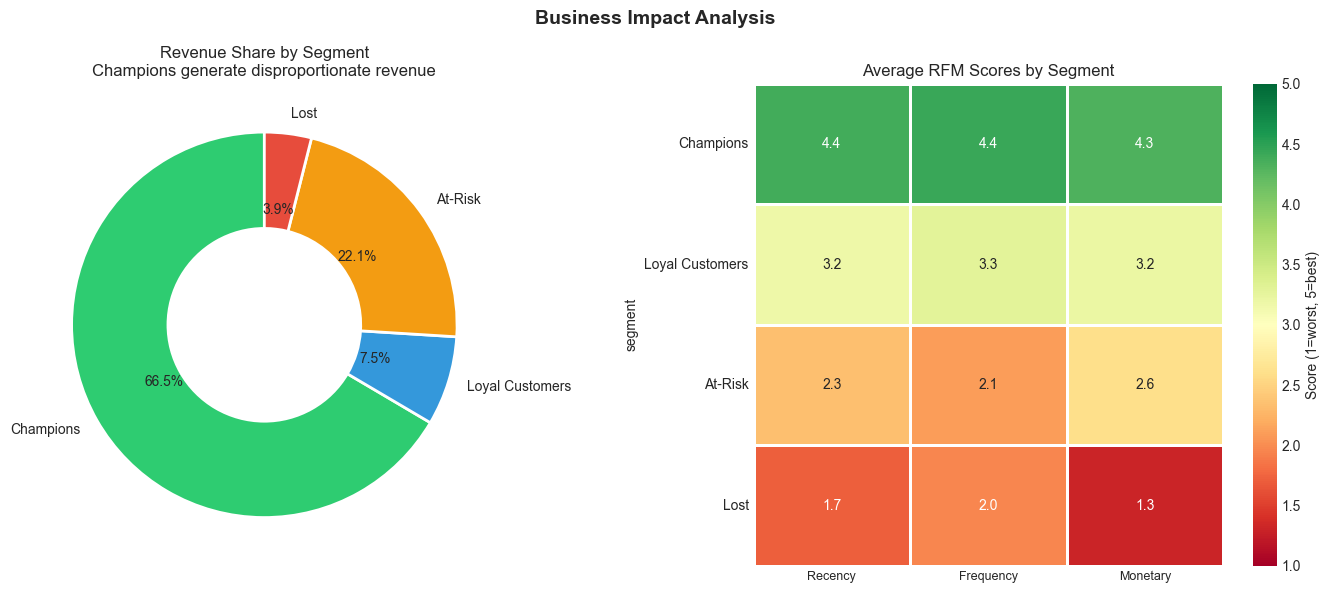

💾 Saved: cs_06_business_impact.png


In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Business Impact Analysis', fontsize=14, fontweight='bold')


seg_rev   = df.groupby('segment')['monetary'].sum()
rev_vals  = [seg_rev.get(s, 0) for s in SEG_ORDER]
axes[0].pie(rev_vals, labels=SEG_ORDER, autopct='%1.1f%%',
    colors=[SEG_COLORS[s] for s in SEG_ORDER],
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2), startangle=90)
axes[0].set_title('Revenue Share by Segment\nChampions generate disproportionate revenue')

rfm_hm = df.groupby('segment')[['R_score', 'F_score', 'M_score']].mean()
rfm_hm = rfm_hm.reindex([s for s in SEG_ORDER if s in rfm_hm.index])
sns.heatmap(rfm_hm, annot=True, fmt='.1f', cmap='RdYlGn', vmin=1, vmax=5, 
    linewidths=0.8, linecolor='white', ax=axes[1],
    cbar_kws={'label': 'Score (1=worst, 5=best)'}) # rating 
axes[1].set_title('Average RFM Scores by Segment')
axes[1].set_xticklabels(['Recency', 'Frequency', 'Monetary'], fontsize=9)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('cs_06_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cs_06_business_impact.png')

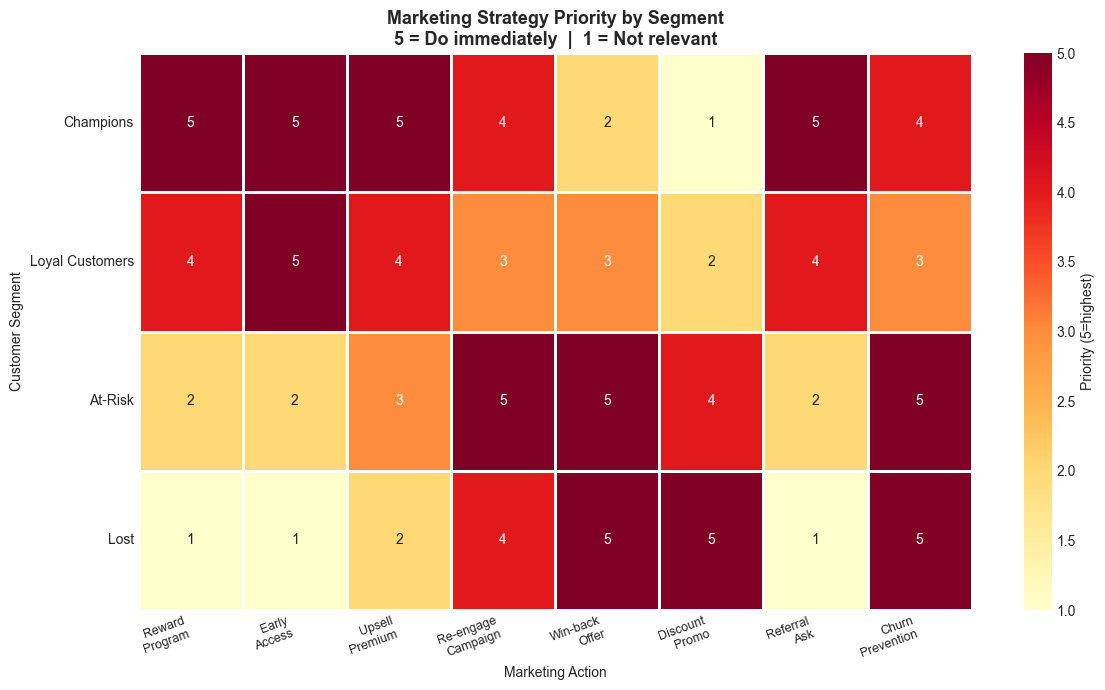

💾 Saved: cs_07_marketing_strategy.png


In [ ]:

strategy_data = {
    'Champions'      : [5, 5, 5, 4, 2, 1, 5, 4],
    'Loyal Customers': [4, 5, 4, 3, 3, 2, 4, 3],
    'At-Risk'        : [2, 2, 3, 5, 5, 4, 2, 5],
    'Lost'           : [1, 1, 2, 4, 5, 5, 1, 5],
}
strategies = [
    'Reward\nProgram', 'Early\nAccess', 'Upsell\nPremium',
    'Re-engage\nCampaign', 'Win-back\nOffer', 'Discount\nPromo',
    'Referral\nAsk', 'Churn\nPrevention'
]

strat_df = pd.DataFrame(strategy_data, index=strategies)
plt.figure(figsize=(12, 7))
sns.heatmap(strat_df.T, annot=True, fmt='d', cmap='YlOrRd', vmin=1, vmax=5,
    linewidths=0.8, linecolor='white', cbar_kws={'label': 'Priority (5=highest)'})
plt.title('Marketing Strategy Priority by Segment\n'
    '5 = Do immediately  |  1 = Not relevant', fontsize=13, fontweight='bold')
plt.xlabel('Marketing Action'); plt.ylabel('Customer Segment')
plt.xticks(rotation=20, ha='right', fontsize=9); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cs_07_marketing_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cs_07_marketing_strategy.png')


## Step 10: 3D PCA Visualisation


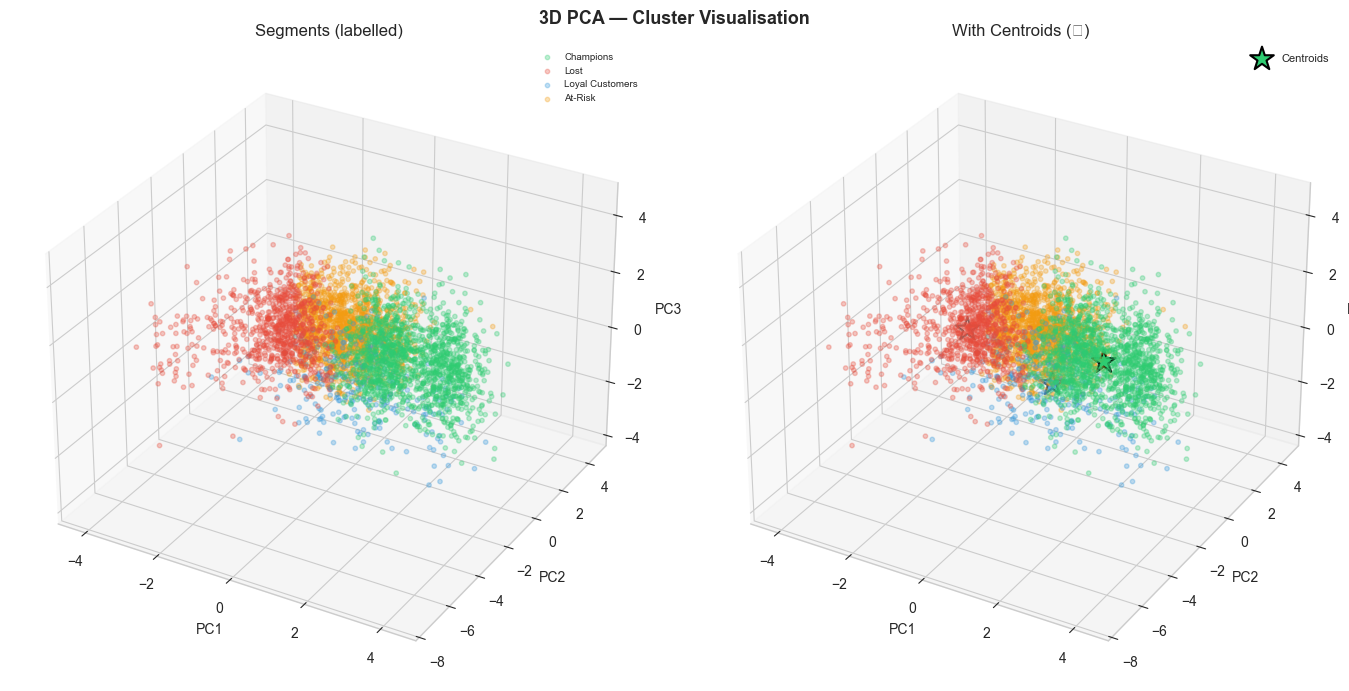

💾 Saved: cs_08_3d_pca.png


In [ ]:

pca3d = PCA(n_components=3, random_state=SEED) 
X_3d  = pca3d.fit_transform(X_scaled)
CLR   = [SEG_COLORS[LABEL_MAP[k]] for k in range(K_BEST)]

fig = plt.figure(figsize=(14, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')
fig.suptitle('3D PCA — Cluster Visualisation', fontsize=13, fontweight='bold')

for k in range(K_BEST):
    m = df['kmeans_cluster'] == k
    ax1.scatter(X_3d[m, 0], X_3d[m, 1], X_3d[m, 2],
        c=CLR[k], alpha=0.3, s=10, label=LABEL_MAP[k])
ax1.set_title('Segments (labelled)'); ax1.legend(fontsize=7)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.set_zlabel('PC3')

for k in range(K_BEST):
    m = df['kmeans_cluster'] == k
    ax2.scatter(X_3d[m, 0], X_3d[m, 1], X_3d[m, 2], c=CLR[k], alpha=0.3, s=10)
ctr3d = pca3d.transform(kmeans.cluster_centers_)
ax2.scatter(ctr3d[:, 0], ctr3d[:, 1], ctr3d[:, 2],
    c=CLR, s=320, marker='*', edgecolors='black', lw=1.5, zorder=10, label='Centroids')
ax2.set_title('With Centroids (★)'); ax2.legend(fontsize=8)
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_zlabel('PC3')

plt.tight_layout()
plt.savefig('cs_08_3d_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cs_08_3d_pca.png')



## Step 11: Predict Segment for a New Customer


In [ ]:
# 1️⃣ Input features 
def predict_segment(recency_days, frequency, monetary,
                    avg_order_value=None, num_categories=3,
                    num_returns=0, promo_used=2,
                    avg_rating_given=4.0, mobile_orders_pct=60.0,
                    days_as_customer=365):
    """
    Predict the K-Means segment for a new customer.

    Parameters match the dataset columns.
    Returns segment name and nearest-centroid distance.
    """
# 2️⃣ Avg Order Value calculate
    if avg_order_value is None:
        avg_order_value = monetary / max(frequency, 1)

# 3️⃣ DataFrame
    raw = pd.DataFrame([{
        'recency_days':      recency_days,
        'frequency':         frequency,
        'monetary':          monetary,
        'avg_order_value':   avg_order_value,
        'num_categories':    num_categories,
        'num_returns':       num_returns,
        'promo_used':        promo_used,
        'avg_rating_given':  avg_rating_given,
        'mobile_orders_pct': mobile_orders_pct,
        'days_as_customer':  days_as_customer,
    }])

# 4️⃣ Skewed features log transform- Apply same log-transforms
    for col in SKEWED:
        raw[f'log_{col}'] = np.log1p(raw[col])
        raw.drop(columns=[col], inplace=True)

    raw_scaled = scaler.transform(raw[feature_names]) # 5️⃣ Scaling (StandardScaler)
    cluster_id = kmeans.predict(raw_scaled)[0] # 6️⃣ Cluster predict (KMeans)
    dist       = np.linalg.norm(raw_scaled - kmeans.cluster_centers_[cluster_id]) # 7️⃣ Distance (confidence measure)

    segment    = LABEL_MAP[cluster_id] # 8️⃣ Segment label map , 0 - champian, 1 lost, 2 loyel, 3 at risk

# 9️⃣ RFM scoring (extra insight)
    r_score = int(pd.cut([recency_days], bins=df['recency_days'].quantile([0,.2,.4,.6,.8,1]).tolist(), labels=[5,4,3,2,1])[0])
    m_score = int(pd.cut([monetary], bins=df['monetary'].quantile([0,.2,.4,.6,.8,1]).tolist(), labels=[1,2,3,4,5])[0])

    print('━'*50)
    print('  🛒 CUSTOMER SEGMENT PREDICTION')
    print('━'*50)
    print(f'  Recency   : {recency_days} days ago')
    print(f'  Frequency : {frequency} orders/year')
    print(f'  Monetary  : ₹{monetary:,.0f}')
    print(f'  Avg Order : ₹{avg_order_value:,.0f}')
    print('━'*50)
    print(f'  Cluster   : {cluster_id}')
    print(f'  Segment   : {segment}')
    print(f'  Confidence: {"High" if dist < 1.5 else "Medium" if dist < 2.5 else "Low"}  (dist={dist:.2f})')
    print('━'*50)

    actions = {
        'Champions':       '🏆 Reward! Loyalty points + referral ask.',
        'Loyal Customers': '💙 Upsell premium + subscription offer.',
        'At-Risk':         '⚠️  Win-back email — personalised 25% discount.',
        'Lost':            '🔴 Last resort: 40-50% discount or remove from CRM.',
    }
    print(f'  Action    : {actions[segment]}')
    print('━'*50)
    return segment

# Test cases
print('=== High-value recent customer ===')
predict_segment(recency_days=8, frequency=22, monetary=35000, days_as_customer=900)

print('\n=== Slipping away customer ===')
predict_segment(recency_days=145, frequency=4, monetary=5500, days_as_customer=400)

print('\n=== Churned customer ===')
predict_segment(recency_days=340, frequency=1, monetary=1200, days_as_customer=150)


=== High-value recent customer ===
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🛒 CUSTOMER SEGMENT PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Recency   : 8 days ago
  Frequency : 22 orders/year
  Monetary  : ₹35,000
  Avg Order : ₹1,591
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cluster   : 0
  Segment   : Champions
  Confidence: Medium  (dist=2.02)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Action    : 🏆 Reward! Loyalty points + referral ask.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

=== Slipping away customer ===
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🛒 CUSTOMER SEGMENT PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Recency   : 145 days ago
  Frequency : 4 orders/year
  Monetary  : ₹5,500
  Avg Order : ₹1,375
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cluster   : 3
  Segment   : At-Risk
  Confidence: High  (dist=1.12)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Action    : ⚠️ 

'Lost'

---
## Step 12: Export Segmented Data & Final Report

In [ ]:
# Save enriched customer CSV
export_cols = ['customer_id', 'city', 'age', 'gender',
               'recency_days', 'frequency', 'monetary', 'avg_order_value',
               'R_score', 'F_score', 'M_score', 'RFM_score',
               'kmeans_cluster', 'segment']
df[export_cols].to_csv('customers_segmented.csv', index=False)
print('✅ Saved: customers_segmented.csv\n')

# Business report
print(f'{"="*65}')
print(f'       CUSTOMER SEGMENTATION REPORT — K-Means (K=4)')
print(f'{"="*65}')
print(f'  Total Customers     : {len(df):,}')
print(f'  Total Revenue (₹)   : {df["monetary"].sum():>15,.0f}')
print(f'  Silhouette Score    : {sil:.4f}')
print(f'  Davies-Bouldin      : {db:.4f}')
print(f'  DBSCAN noise points : {n_nois} ({n_nois/len(df)*100:.1f}%)')
print(f'{"─"*65}')
print(f'  {"Segment":<18} {"Count":>6} {"Recency":>9} {"Freq":>6} {"Avg Spend":>12} {"Rev%":>8}')
print(f'{"─"*65}')
for seg in SEG_ORDER:
    sub = df[df['segment'] == seg]
    if len(sub):
        rev_pct = sub['monetary'].sum() / df['monetary'].sum() * 100
        print(f'  {seg:<18} {len(sub):>6,} {sub["recency_days"].mean():>9.0f}d '
              f'{sub["frequency"].mean():>6.1f} {sub["monetary"].mean():>12,.0f} {rev_pct:>7.1f}%')
print(f'{"─"*65}')
print(f'\n  MARKETING ACTIONS:')
acts = {
    'Champions'      : 'Reward + referral program + early access',
    'Loyal Customers': 'Upsell premium + subscription offers',
    'At-Risk'        : 'Personalised win-back email with 25% discount',
    'Lost'           : 'Aggressive 40-50% discount or CRM removal , heavy discount or ignore',
}
for seg, act in acts.items():
    print(f'  {seg:<18}: {act}')
print(f'{"="*65}')


✅ Saved: customers_segmented.csv

       CUSTOMER SEGMENTATION REPORT — K-Means (K=4)
  Total Customers     : 4,000
  Total Revenue (₹)   :      44,136,215
  Silhouette Score    : 0.1157
  Davies-Bouldin      : 2.1285
  DBSCAN noise points : 20 (0.5%)
─────────────────────────────────────────────────────────────────
  Segment             Count   Recency   Freq    Avg Spend     Rev%
─────────────────────────────────────────────────────────────────
  Champions           1,449        30d   14.5       20,263    66.5%
  Loyal Customers       283        98d    8.8       11,677     7.5%
  At-Risk             1,434       155d    4.2        6,787    22.1%
  Lost                  834       224d    3.9        2,085     3.9%
─────────────────────────────────────────────────────────────────

  MARKETING ACTIONS:
  Champions         : Reward + referral program + early access
  Loyal Customers   : Upsell premium + subscription offers
  At-Risk           : Personalised win-back email with 25% discount


**GitHub README:**
- Embed `cs_03_pca_clusters.png` — the money shot
- Embed `cs_07_marketing_strategy.png` — shows business translation
- Include the segment summary table